In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Handling imbalance
from imblearn.over_sampling import SMOTE


In [2]:
df = pd.read_csv("menstrual_cycle_dataset_with_factors.csv")
df.head()


,User ID,Age,BMI,Stress Level,Exercise Frequency,Sleep Hours,Diet,Cycle Start Date,Cycle Length,Period Length,Next Cycle Start Date,Symptoms
0,1,18,29.28,2,Moderate,5.4,Low Carb,2024-11-13 20:52:34.915012,26,7,2024-12-09 20:52:34.915012,Headache
1,1,18,29.28,2,Moderate,5.4,Low Carb,2024-12-09 20:52:34.915012,32,5,2025-01-10 20:52:34.915012,Fatigue
2,1,18,29.28,2,Moderate,5.4,Low Carb,2025-01-10 20:52:34.915012,41,7,2025-02-20 20:52:34.915012,Fatigue
3,1,18,29.28,2,Moderate,5.4,Low Carb,2025-02-20 20:52:34.915012,27,3,2025-03-19 20:52:34.915012,Fatigue
4,1,18,29.28,2,Moderate,5.4,Low Carb,2025-03-19 20:52:34.915012,42,5,2025-04-30 20:52:34.915012,Cramps


In [3]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   User ID                895 non-null    int64  
 1   Age                    895 non-null    int64  
 2   BMI                    895 non-null    float64
 3   Stress Level           895 non-null    int64  
 4   Exercise Frequency     895 non-null    object 
 5   Sleep Hours            895 non-null    float64
 6   Diet                   895 non-null    object 
 7   Cycle Start Date       895 non-null    object 
 8   Cycle Length           895 non-null    int64  
 9   Period Length          895 non-null    int64  
 10  Next Cycle Start Date  895 non-null    object 
 11  Symptoms               895 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 84.0+ KB


,0
User ID,0
Age,0
BMI,0
Stress Level,0
Exercise Frequency,0
Sleep Hours,0
Diet,0
Cycle Start Date,0
Cycle Length,0
Period Length,0


In [4]:
df["Irregular_Cycle"] = np.where(
    (df["Cycle Length"] < 21) | (df["Cycle Length"] > 35),
    1, 0
)

In [5]:
df["Irregular_Cycle"].value_counts()


,count
Irregular_Cycle,
1,503
0,392


In [6]:
cols_to_drop = [
    "User ID",
    "Cycle Start Date",
    "Next Cycle Start Date"
]
existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df_model = df.drop(columns=existing_cols_to_drop)

In [7]:
X = df_model.drop(columns=["Irregular_Cycle"])
y = df_model["Irregular_Cycle"]


In [8]:
cat_cols = X.select_dtypes(include=['object']).columns


In [9]:
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])


In [10]:
num_cols = X.select_dtypes(include=['int64','float64']).columns


In [11]:
num_imputer = SimpleImputer(strategy='median')
X[num_cols] = num_imputer.fit_transform(X[num_cols])


In [12]:
X_original=X.copy()

In [13]:
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])


In [14]:
X_train, X_test, y_train, y_test , X_train_orig,X_test_orig = train_test_split(
    X, y,X_original,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
# Identify and re-encode any remaining object columns in X_train
object_cols_in_xtrain = X_train.select_dtypes(include=['object']).columns

if len(object_cols_in_xtrain) > 0:
    print(f"Warning: X_train still contains object columns: {list(object_cols_in_xtrain)}. Encoding them now for SMOTE.")
    for col in object_cols_in_xtrain:
        # Create a new LabelEncoder instance for each column.
        # This approach ensures X_train is numerical for SMOTE,
        # but it's important to remember that this encoder is not
        # applied to X_test, potentially leading to inconsistency.
        # For consistent preprocessing, LabelEncoder should be fitted
        # on the entire dataset X before train-test split.
        local_le = LabelEncoder()
        X_train[col] = local_le.fit_transform(X_train[col])

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [16]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

In [17]:
rf.fit(X_train_smote, y_train_smote)


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [18]:
# Re-encode categorical columns in X_test for consistency with X_train_smote
# Note: This is a workaround as the original LabelEncoder application in VwxZYO7fSfXF was ineffective.
# Ideally, LabelEncoder should be applied consistently to X before train-test split.
cat_cols_for_test = ['Exercise Frequency', 'Diet', 'Symptoms']
for col in cat_cols_for_test:
    if col in X_test.columns and X_test[col].dtype == 'object':
        # Create a new LabelEncoder instance. This might lead to inconsistent mappings
        # if the order of categories in X_test differs significantly from X_train,
        # but it will resolve the ValueError.
        le_test = LabelEncoder()
        X_test[col] = le_test.fit_transform(X_test[col])

y_pred_rf = rf.predict(X_test)

In [19]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        78
           1       1.00      1.00      1.00       101

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



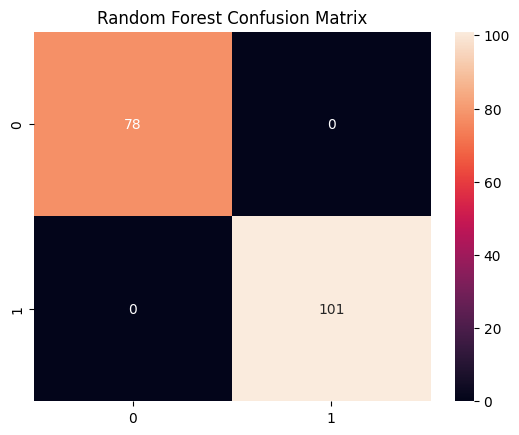

In [20]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()


In [21]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

In [22]:
xgb.fit(X_train_smote, y_train_smote)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [23]:
y_pred_xgb = xgb.predict(X_test)


In [24]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        78
           1       1.00      1.00      1.00       101

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



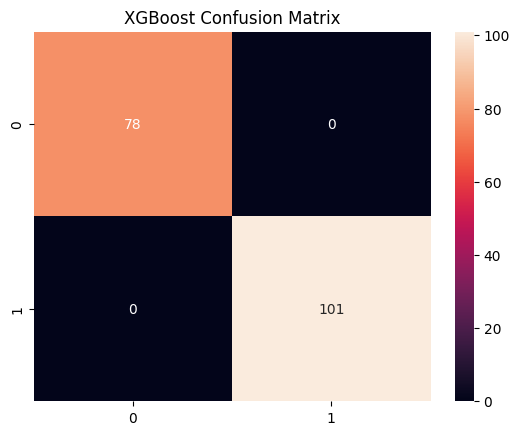

In [25]:
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d')
plt.title("XGBoost Confusion Matrix")
plt.show()


In [26]:
risk_probs = xgb.predict_proba(X_test)[:, 1]


In [27]:
def risk_category(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.6:
        return "Moderate Risk"
    else:
        return "High Risk"


In [28]:
risk_labels = [risk_category(p) for p in risk_probs]


In [29]:
risk_df = X_test_orig.copy()
risk_df["Actual_Label"] = y_test.values
risk_df["Risk_Probability"] = risk_probs
risk_df["Risk_Category"] = risk_labels


In [30]:
risk_df.head()


,Age,BMI,Stress Level,Exercise Frequency,Sleep Hours,Diet,Cycle Length,Period Length,Symptoms,Actual_Label,Risk_Probability,Risk_Category
657,27.0,21.79,4.0,0.0,5.6,0.0,45.0,7.0,1.0,1,0.997582,High Risk
610,31.0,21.93,1.0,1.0,8.8,0.0,30.0,5.0,2.0,0,0.002418,Low Risk
872,19.0,21.71,4.0,2.0,5.7,2.0,31.0,3.0,2.0,0,0.002418,Low Risk
101,20.0,28.33,5.0,1.0,5.8,1.0,36.0,5.0,1.0,1,0.997582,High Risk
608,31.0,21.93,1.0,1.0,8.8,0.0,39.0,6.0,1.0,1,0.997582,High Risk


In [31]:
risk_df.to_csv("Menstrual_Cycle_Risk_Prediction.csv", index=False)


In [32]:
from google.colab import files
files.download("Menstrual_Cycle_Risk_Prediction.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        78
           1       1.00      1.00      1.00       101

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



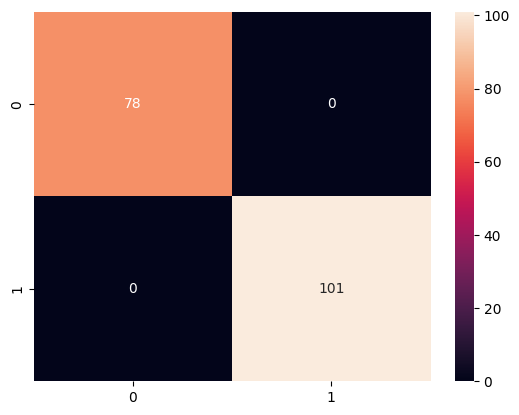

XGBoost Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        78
           1       1.00      1.00      1.00       101

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



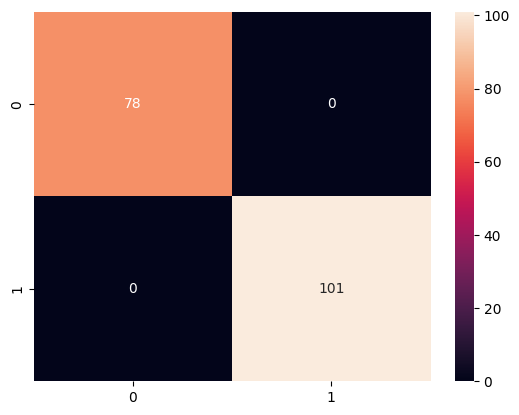

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
!pip install imbalanced-learn xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from google.colab import files

# ================= LOAD DATA =================
df = pd.read_csv("menstrual_cycle_dataset_with_factors.csv")

# ================= TARGET CREATION =================
df["Irregular_Cycle"] = np.where(
    (df["Cycle Length"] < 21) | (df["Cycle Length"] > 35), 1, 0
)

# ================= DROP USELESS COLUMNS =================
cols_to_drop = ["User ID", "Cycle Start Date", "Next Cycle Start Date"]
df_model = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# ================= SPLIT X & y =================
X = df_model.drop("Irregular_Cycle", axis=1)
y = df_model["Irregular_Cycle"]

# Keep original for final CSV
X_original = X.copy()

# ================= ENCODE CATEGORICAL BEFORE SPLIT ✅ =================
cat_cols = X.select_dtypes(include="object").columns
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# ================= HANDLE MISSING =================
num_cols = X.select_dtypes(include=['int64','float64']).columns
imputer = SimpleImputer(strategy="median")
X[num_cols] = imputer.fit_transform(X[num_cols])

# ================= SCALING =================
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# ================= TRAIN TEST SPLIT =================
X_train, X_test, y_train, y_test, X_train_orig, X_test_orig = train_test_split(
    X, y, X_original,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================= SMOTE =================
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# ================= RANDOM FOREST =================
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.show()

# ================= XGBOOST =================
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d')
plt.show()

# ================= RISK PREDICTION =================
risk_probs = xgb.predict_proba(X_test)[:, 1]

def risk_category(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.6:
        return "Moderate Risk"
    else:
        return "High Risk"

risk_df = X_test_orig.copy()

risk_df["Actual_Label"] = y_test.values
risk_df["Predicted_Label"] = y_pred_xgb
risk_df["Risk_Probability"] = risk_probs
risk_df["Risk_%"] = risk_probs * 100
risk_df["Risk_Category"] = [risk_category(p) for p in risk_probs]

# ================= SAVE CSV =================
risk_df.to_csv("Menstrual_Cycle_Risk_Prediction.csv", index=False)
files.download("Menstrual_Cycle_Risk_Prediction.csv")

# ================= SAVE MODEL =================
joblib.dump(xgb, "menstrual_xgb_model.pkl")
joblib.dump(scaler, "scaler.pkl")

files.download("menstrual_xgb_model.pkl")
files.download("scaler.pkl")

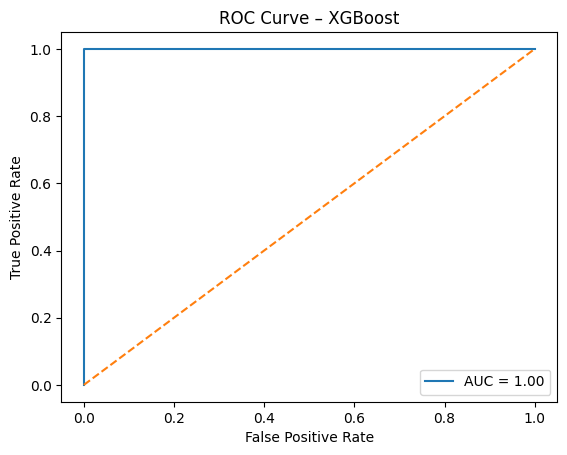

In [34]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, risk_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost")
plt.legend()
plt.show()